<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/01-data-preprocessing/feature-encoding/Feature_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Encoding

## Importing necceury libraies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
path_file = '/content/Health_Insurance.csv'
df = pd.read_csv(path_file)

## EDA

In [3]:
df.head()

,Gender,Education,Age,Income,Region,Employment_Status,Marital_Status,Credit_Rating,Car_Brand,Target
0,Female,Master,24,90003,West,Self-Employed,Single,Poor,Toyota,No
1,Female,High School,56,96394,West,Employed,Divorced,Fair,Honda,No
2,Female,PhD,61,43637,North,Self-Employed,Single,Poor,Ford,Yes
3,Male,PhD,48,74508,West,Employed,Married,Excellent,Chevrolet,Yes
4,Female,Bachelor,24,42470,West,Self-Employed,Married,Poor,Nissan,Yes


In [4]:
print(f"Shape of the dataset is {df.shape}")

Shape of the dataset is (500, 10)


In [5]:
df.columns

Index(['Gender', 'Education', 'Age', 'Income', 'Region', 'Employment_Status',
       'Marital_Status', 'Credit_Rating', 'Car_Brand', 'Target'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             500 non-null    object
 1   Education          500 non-null    object
 2   Age                500 non-null    int64 
 3   Income             500 non-null    int64 
 4   Region             500 non-null    object
 5   Employment_Status  500 non-null    object
 6   Marital_Status     500 non-null    object
 7   Credit_Rating      500 non-null    object
 8   Car_Brand          500 non-null    object
 9   Target             500 non-null    object
dtypes: int64(2), object(8)
memory usage: 39.2+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,40.572,13.727261,18.0,29.0,41.0,52.00,64.0
Income,500.0,62876.954,22124.497989,25163.0,43659.5,62447.5,82469.75,99694.0


In [8]:
cat_cols = df.select_dtypes(include=['object'])
cat_cols.columns

Index(['Gender', 'Education', 'Region', 'Employment_Status', 'Marital_Status',
       'Credit_Rating', 'Car_Brand', 'Target'],
      dtype='object')

## Preprocessing

### Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

lable_encoder = LabelEncoder()
df['Target'] = lable_encoder.fit_transform(df['Target'])

df.head()

,Gender,Education,Age,Income,Region,Employment_Status,Marital_Status,Credit_Rating,Car_Brand,Target
0,Female,Master,24,90003,West,Self-Employed,Single,Poor,Toyota,0
1,Female,High School,56,96394,West,Employed,Divorced,Fair,Honda,0
2,Female,PhD,61,43637,North,Self-Employed,Single,Poor,Ford,1
3,Male,PhD,48,74508,West,Employed,Married,Excellent,Chevrolet,1
4,Female,Bachelor,24,42470,West,Self-Employed,Married,Poor,Nissan,1


### One Hot Encoding

In [10]:
nominal_columns = ['Gender', 'Region', 'Employment_Status', 'Marital_Status', 'Car_Brand']

for i in nominal_columns:
  print(f"{i} : {df[i].unique()}")
  print(f"{i} : {df[i].nunique()}")
  print(df[i].value_counts())
  print()


Gender : ['Female' 'Male']
Gender : 2
Gender
Male      267
Female    233
Name: count, dtype: int64

Region : ['West' 'North' 'East' 'South']
Region : 4
Region
East     136
West     133
South    119
North    112
Name: count, dtype: int64

Employment_Status : ['Self-Employed' 'Employed' 'Unemployed']
Employment_Status : 3
Employment_Status
Employed         186
Self-Employed    159
Unemployed       155
Name: count, dtype: int64

Marital_Status : ['Single' 'Divorced' 'Married']
Marital_Status : 3
Marital_Status
Married     176
Divorced    163
Single      161
Name: count, dtype: int64

Car_Brand : ['Toyota' 'Honda' 'Ford' 'Chevrolet' 'Nissan' 'Volkswagen' 'Hyundai' 'Kia'
 'Subaru' 'Mazda' 'BMW' 'Mercedes' 'Audi' 'Lexus' 'Porsche' 'Jeep' 'Ram'
 'Dodge' 'Chrysler' 'Cadillac' 'Volvo' 'Jaguar' 'Land Rover' 'Fiat' 'Mini'
 'Tesla' 'Mitsubishi' 'Infiniti' 'Acura' 'Lincoln']
Car_Brand : 30
Car_Brand
Toyota        40
Honda         40
Ford          40
Chevrolet     40
Nissan        40
Volkswagen    3

In [11]:
# Method 1: One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

df1 = df.copy()

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')

columns_to_encode = ['Gender', 'Region', 'Employment_Status', 'Marital_Status']

encoded_columns = onehot_encoder.fit_transform(df1[columns_to_encode])

encoded_columns_df1 = pd.DataFrame(encoded_columns,
                                   columns=onehot_encoder.get_feature_names_out(
                                       input_features=columns_to_encode))

df1 = pd.concat([df1, encoded_columns_df1], axis=1)

df1 = df1.drop(columns=columns_to_encode)

df1.head()

,Education,Age,Income,Credit_Rating,Car_Brand,Target,Gender_Male,Region_North,Region_South,Region_West,Employment_Status_Self-Employed,Employment_Status_Unemployed,Marital_Status_Married,Marital_Status_Single
0,Master,24,90003,Poor,Toyota,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,High School,56,96394,Fair,Honda,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,PhD,61,43637,Poor,Ford,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,PhD,48,74508,Excellent,Chevrolet,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,Bachelor,24,42470,Poor,Nissan,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [12]:
# Method 2: One Hot Encoding

df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)
df.head()

,Education,Age,Income,Credit_Rating,Car_Brand,Target,Gender_Male,Region_North,Region_South,Region_West,Employment_Status_Self-Employed,Employment_Status_Unemployed,Marital_Status_Married,Marital_Status_Single
0,Master,24,90003,Poor,Toyota,0,0,0,0,1,1,0,0,1
1,High School,56,96394,Fair,Honda,0,0,0,0,1,0,0,0,0
2,PhD,61,43637,Poor,Ford,1,0,1,0,0,1,0,0,1
3,PhD,48,74508,Excellent,Chevrolet,1,1,0,0,1,0,0,1,0
4,Bachelor,24,42470,Poor,Nissan,1,0,0,0,1,1,0,1,0


One Hot Encoding for features with too many categories

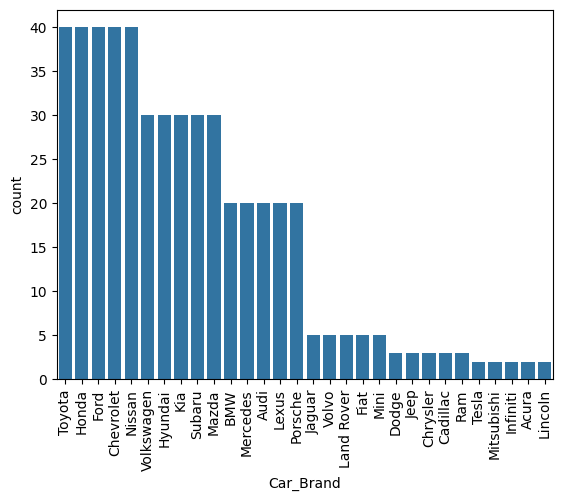

In [13]:
df2 = df.copy()

sns.countplot(data=df2, x='Car_Brand', order=df2['Car_Brand'].value_counts().index)
plt.xticks(rotation=90)

frequency = df2['Car_Brand'].value_counts()

In [14]:
min_threshold = 25

features_to_club = frequency[frequency < min_threshold].index

df2['Car_Brand'].replace(features_to_club, 'other', inplace=True)

df2['Car_Brand'].nunique()

11

In [15]:
df2['Car_Brand'].value_counts().sort_values(ascending=False)

,count
Car_Brand,
other,150
Honda,40
Toyota,40
Ford,40
Chevrolet,40
Nissan,40
Volkswagen,30
Hyundai,30
Kia,30


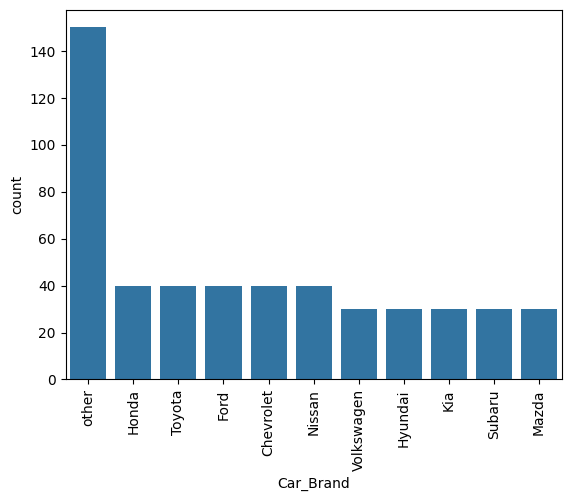

In [16]:
sns.countplot(data=df2, x='Car_Brand', order=df2['Car_Brand'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

In [17]:
df2 = pd.get_dummies(df2, columns=['Car_Brand'], drop_first=True, dtype=int)
df2.head()

,Education,Age,Income,Credit_Rating,Target,Gender_Male,Region_North,Region_South,Region_West,Employment_Status_Self-Employed,...,Car_Brand_Ford,Car_Brand_Honda,Car_Brand_Hyundai,Car_Brand_Kia,Car_Brand_Mazda,Car_Brand_Nissan,Car_Brand_Subaru,Car_Brand_Toyota,Car_Brand_Volkswagen,Car_Brand_other
0,Master,24,90003,Poor,0,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0
1,High School,56,96394,Fair,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,PhD,61,43637,Poor,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,0
3,PhD,48,74508,Excellent,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Bachelor,24,42470,Poor,1,0,0,0,1,1,...,0,0,0,0,0,1,0,0,0,0


In [18]:
df2.columns

Index(['Education', 'Age', 'Income', 'Credit_Rating', 'Target', 'Gender_Male',
       'Region_North', 'Region_South', 'Region_West',
       'Employment_Status_Self-Employed', 'Employment_Status_Unemployed',
       'Marital_Status_Married', 'Marital_Status_Single', 'Car_Brand_Ford',
       'Car_Brand_Honda', 'Car_Brand_Hyundai', 'Car_Brand_Kia',
       'Car_Brand_Mazda', 'Car_Brand_Nissan', 'Car_Brand_Subaru',
       'Car_Brand_Toyota', 'Car_Brand_Volkswagen', 'Car_Brand_other'],
      dtype='object')

In [19]:
df2.shape[1]

23

### Ordinal Encoding

In [20]:
from sklearn.preprocessing import OrdinalEncoder

education_order = ['High School', 'Bachelor', 'Master', 'PhD']

ordinal_encoder = OrdinalEncoder(categories=[education_order])

df['Education_encoded'] = ordinal_encoder.fit_transform(df[['Education']])

df[['Education', 'Education_encoded']].head()

,Education,Education_encoded
0,Master,2.0
1,High School,0.0
2,PhD,3.0
3,PhD,3.0
4,Bachelor,1.0


In [21]:
df.drop('Education', axis=1, inplace=True)

### Custom Encoding

In [22]:
df['Credit_Rating'].unique()

array(['Poor', 'Fair', 'Excellent', 'Good'], dtype=object)

In [23]:
custom_encoding = {'Excellent' : 10,
                   'Good' : 7,
                   'Fair' : 3,
                   'Poor' : 1}

df['Credit_Rating_encoded'] = df['Credit_Rating'].replace(custom_encoding)

df[['Credit_Rating', 'Credit_Rating_encoded']].sample(10)

,Credit_Rating,Credit_Rating_encoded
194,Excellent,10
344,Fair,3
3,Excellent,10
460,Excellent,10
341,Good,7
361,Poor,1
434,Fair,3
79,Good,7
368,Excellent,10
328,Poor,1


In [24]:
df.drop('Credit_Rating', axis=1, inplace=True)

### Target Encoding

In [26]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [27]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['Car_Brand'])

df = encoder.fit_transform(df, df['Target'])

df = df.rename(columns={'Car_Brand' : 'Car_Brand_encoded'})

df.head()

,Age,Income,Car_Brand_encoded,Target,Gender_Male,Region_North,Region_South,Region_West,Employment_Status_Self-Employed,Employment_Status_Unemployed,Marital_Status_Married,Marital_Status_Single,Education_encoded,Credit_Rating_encoded
0,24,90003,0.499046,0,0,0,0,1,1,0,0,1,2.0,1
1,56,96394,0.455007,0,0,0,0,1,0,0,0,0,0.0,3
2,61,43637,0.543086,1,0,1,0,0,1,0,0,1,3.0,1
3,48,74508,0.477026,1,1,0,0,1,0,0,1,0,3.0,10
4,24,42470,0.499046,1,0,0,0,1,1,0,1,0,1.0,1
